# BioASQ Results Analysis
Static analysis and plots for BM25, Dense, Hybrid, and rerankers (MiniLM, BGE v2).

## 1. Imports and Setup

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 2. Set Input Paths

In [3]:
base_dir = Path.cwd().resolve()
if not (base_dir / "output").exists() and (base_dir.parent / "output").exists():
    # Notebook run from notebooks/ or a subdir
    base_dir = base_dir.parent

print("Base dir:", base_dir)

Base dir: /Users/yun/develop/BioASQ


In [4]:
results = {
    "BM25+RM3": base_dir / "output/eval_bm25_rm3",
    "Dense (MedEmbed)": base_dir / "output/eval_dense_medembed_small",
    "Hybrid (RRF)": base_dir / "output/eval_hybird_production_test",
    "Reranker MiniLM": base_dir / "output/eval_stage2_rerank",
    "BGE v2 (len=200)": base_dir / "output/eval_stage2_rerank_bge_reranker_v2_m3_len200",
    "BGE v2 (len=512)": base_dir / "output/eval_stage2_rerank_bge_reranker_v2_m3_len512",
}

output_dir = base_dir / "output" / "analysis_output"
figures_dir = output_dir / "figures"
output_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print("Outputs:", output_dir)
print("Methods:", list(results.keys()))

Outputs: /Users/yun/develop/BioASQ/output/analysis_output
Methods: ['BM25+RM3', 'Dense (MedEmbed)', 'Hybrid (RRF)', 'Reranker MiniLM', 'BGE v2 (len=200)', 'BGE v2 (len=512)']


## 3. Load Configuration and Run Metrics

In [5]:
def load_metrics_from_dir(result_dir: Path) -> pd.DataFrame | None:
    result_dir = Path(result_dir)
    metrics_file = result_dir / "rerank_metrics.csv"
    if not metrics_file.exists():
        metrics_file = result_dir / "metrics.csv"
    if metrics_file.exists():
        df = pd.read_csv(metrics_file)
        if "split" not in df.columns and "batch" in df.columns:
            df["split"] = df["batch"]
        return df

    # Hybrid outputs recall-focused tables in results_all.csv
    results_all = result_dir / "results_all.csv"
    if results_all.exists():
        df = pd.read_csv(results_all)
        best_cfg = result_dir / "best_config.json"
        if best_cfg.exists():
            with best_cfg.open("r", encoding="utf-8") as f:
                cfg = json.load(f)
            k_rrf = cfg.get("k_rrf")
            w_bm25 = cfg.get("w_bm25")
            w_dense = cfg.get("w_dense")
            if k_rrf is not None and w_bm25 is not None and w_dense is not None:
                df = df[
                    np.isclose(df["k_rrf"], float(k_rrf))
                    & np.isclose(df["w_bm25"], float(w_bm25))
                    & np.isclose(df["w_dense"], float(w_dense))
                ]
        if "split" not in df.columns and "batch" in df.columns:
            df["split"] = df["batch"]
        return df

    print(f"Missing metrics in {result_dir}")
    return None

all_metrics = {}
for name, result_dir in results.items():
    df = load_metrics_from_dir(result_dir)
    if df is not None and not df.empty:
        all_metrics[name] = df
        print(f"Loaded {name}: {result_dir}")

print("Loaded sets:", len(all_metrics))

Loaded BM25+RM3: /Users/yun/develop/BioASQ/output/eval_bm25_rm3
Loaded Dense (MedEmbed): /Users/yun/develop/BioASQ/output/eval_dense_medembed_small
Loaded Hybrid (RRF): /Users/yun/develop/BioASQ/output/eval_hybird_production_test
Loaded Reranker MiniLM: /Users/yun/develop/BioASQ/output/eval_stage2_rerank
Loaded BGE v2 (len=200): /Users/yun/develop/BioASQ/output/eval_stage2_rerank_bge_reranker_v2_m3_len200
Loaded BGE v2 (len=512): /Users/yun/develop/BioASQ/output/eval_stage2_rerank_bge_reranker_v2_m3_len512
Loaded sets: 6


## 4. Filter and Validate BGE Configs (len=200, len=512)

In [6]:
for bge_len in [200, 512]:
    config_path = base_dir / f"output/eval_stage2_rerank_bge_reranker_v2_m3_len{bge_len}/config.json"
    if not config_path.exists():
        print(f"Missing config for BGE len={bge_len}")
        continue
    with config_path.open("r", encoding="utf-8") as f:
        config = json.load(f)
    model = config.get("model")
    model_max_length = config.get("model_max_length")
    model_batch = config.get("model_batch")
    print(f"BGE len={bge_len}: model={model}, max_length={model_max_length}, batch={model_batch}")
    if model_max_length != bge_len:
        print(f"Warning: expected model_max_length={bge_len}, found {model_max_length}")

BGE len=200: model=BAAI/bge-reranker-v2-m3, max_length=200, batch=512
BGE len=512: model=BAAI/bge-reranker-v2-m3, max_length=512, batch=256


## 5. Consolidate Metrics

In [7]:
rows = []

for method_name, df in all_metrics.items():
    df_copy = df.copy()
    df_copy["method"] = method_name
    rows.append(df_copy)

df_all = pd.concat(rows, ignore_index=True)

if "split" not in df_all.columns:
    raise ValueError("Missing 'split' column after loading metrics.")

def normalize_split(split_name: str) -> str:
    if pd.isna(split_name):
        return split_name
    split_str = str(split_name)
    if split_str.startswith("best_rrf_"):
        split_str = split_str.replace("best_rrf_", "")
        split_str = split_str.replace("_top2000", "")
    return split_str

df_all["split_normalized"] = df_all["split"].apply(normalize_split)

metric_cols = [c for c in df_all.columns if c.startswith("MeanR@")] + ["MAP@10", "GMAP@10", "MRR@10"]
print("Metrics columns:", metric_cols)
print("Splits:", df_all["split_normalized"].unique().tolist())

Metrics columns: ['MeanR@50', 'MeanR@100', 'MeanR@200', 'MeanR@500', 'MeanR@2000', 'MeanR@5000', 'MeanR@1000', 'MeanR@300', 'MeanR@400', 'MeanR@431', 'MeanR@928', 'MeanR@Krec', 'MAP@10', 'GMAP@10', 'MRR@10']
Splits: ['train_subset', '13B1_golden', '13B2_golden', '13B3_golden', '13B4_golden']


## 6. Summary Table - Test Average (13B1-4)

In [8]:
test_splits = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
df_test = df_all[df_all["split_normalized"].isin(test_splits)].copy()

summary_rows = []
for method in df_all["method"].unique():
    method_data = df_test[df_test["method"] == method]
    if method_data.empty:
        continue
    row = {"method": method}
    for col in ["MAP@10", "GMAP@10", "MRR@10", "MeanR@50", "MeanR@100", "MeanR@500", "MeanR@2000"]:
        if col in method_data.columns:
            row[col] = method_data[col].mean()
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).sort_values("MAP@10", ascending=False)
print(df_summary.round(3).to_string(index=False))

summary_path = output_dir / "summary_test_avg.csv"
df_summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

          method  MAP@10  GMAP@10  MRR@10  MeanR@50  MeanR@100  MeanR@500  MeanR@2000
BGE v2 (len=512)   0.418    0.175   0.689     0.573      0.672      0.846       0.907
 Reranker MiniLM   0.385    0.144   0.704     0.525      0.622      0.823       0.907
BGE v2 (len=200)   0.351    0.092   0.637     0.499      0.598      0.796       0.907
    Hybrid (RRF)   0.342    0.088   0.636     0.491      0.597      0.784       0.908
        BM25+RM3   0.305    0.044   0.551     0.452      0.533      0.723       0.844
Dense (MedEmbed)   0.207    0.009   0.385     0.381      0.476      0.687       0.829
Saved: /Users/yun/develop/BioASQ/output/analysis_output/summary_test_avg.csv


## 7. Stage 1 Recall Curves - Train vs Test Avg
Plot train and test average on the same axes. Use only K values that exist for all three stage-1 methods.

Stage 1 K values (fixed + available): [100, 200, 500, 2000, 5000]
Saved: /Users/yun/develop/BioASQ/output/analysis_output/figures/01_stage1_recall_train_test.png


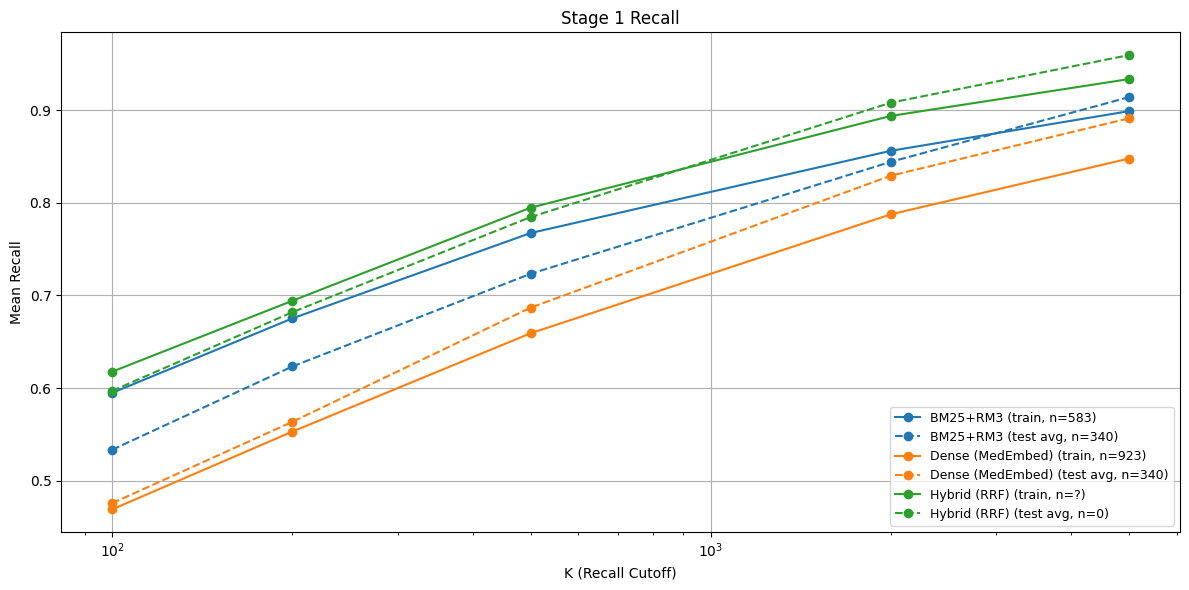

In [ ]:
df_train = df_all[df_all["split_normalized"] == "train_subset"].copy()

test_splits = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
df_test = df_all[df_all["split_normalized"].isin(test_splits)].copy()

stage1_methods = ["BM25+RM3", "Dense (MedEmbed)", "Hybrid (RRF)"]

# Use a fixed K list shared across methods.
fixed_k = [100, 200, 500, 2000, 5000]

# Keep only K values that are present and non-NaN for every method in train and test.
valid_k = []
for k in fixed_k:
    col = f"MeanR@{k}"
    ok = True
    for method in stage1_methods:
        method_train = df_train[df_train["method"] == method]
        method_test = df_test[df_test["method"] == method]
        if method_train.empty or method_test.empty:
            ok = False
            break
        train_val = method_train.iloc[0].get(col)
        test_val = method_test[col].mean() if col in method_test.columns else np.nan
        if pd.isna(train_val) or pd.isna(test_val):
            ok = False
            break
    if ok:
        valid_k.append(k)

k_list = valid_k
if not k_list:
    raise ValueError("No overlapping MeanR@K columns found for stage-1 methods.")

print("Stage 1 K values (fixed + available):", k_list)

colors = {
    "BM25+RM3": "#1f77b4",
    "Dense (MedEmbed)": "#ff7f0e",
    "Hybrid (RRF)": "#2ca02c",
}

fig, ax = plt.subplots()
for method in stage1_methods:
    train_row = df_train[df_train["method"] == method]
    test_rows = df_test[df_test["method"] == method]
    if train_row.empty or test_rows.empty:
        continue
    train_row = train_row.iloc[0]
    train_vals = [train_row.get(f"MeanR@{k}", np.nan) for k in k_list]
    test_vals = [test_rows[f"MeanR@{k}"].mean() for k in k_list]

    color = colors.get(method)
    ax.plot(k_list, train_vals, marker="o", label=f"{method} (train)", color=color)
    ax.plot(k_list, test_vals, marker="o", linestyle="--", label=f"{method} (test avg)", color=color)

ax.set_xlabel("K (Recall Cutoff)")
ax.set_ylabel("Mean Recall")
ax.set_title("Stage 1 Recall")
ax.set_xscale("log")
ax.legend(fontsize=9, loc="lower right")

fig_path = figures_dir / "01_stage1_recall_train_test.png"
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

## 9. Stage 1 Recall and Reranker Quality
Stage 1 retrieval prioritizes recall at large K (overfetch). Then we evaluate rerankers for top-rank precision and whether recall stays strong at smaller K.

In [1]:
df_train = df_all[df_all["split_normalized"] == "train_subset"].copy()

test_splits = ["13B1_golden", "13B2_golden", "13B3_golden", "13B4_golden"]
df_test = df_all[df_all["split_normalized"].isin(test_splits)].copy()

stage1_methods = ["BM25+RM3", "Dense (MedEmbed)", "Hybrid (RRF)"]

# Use a fixed K list shared across methods.
fixed_k = [50, 100, 200, 500, 2000, 5000]

# Keep only K values that are present and non-NaN for every method in train and test.
valid_k = []
for k in fixed_k:
    col = f"MeanR@{k}"
    ok = True
    for method in stage1_methods:
        method_train = df_train[df_train["method"] == method]
        method_test = df_test[df_test["method"] == method]
        if method_train.empty or method_test.empty:
            ok = False
            break
        train_val = method_train.iloc[0].get(col)
        test_val = method_test[col].mean() if col in method_test.columns else np.nan
        if pd.isna(train_val) or pd.isna(test_val):
            ok = False
            break
    if ok:
        valid_k.append(k)

k_list = valid_k
if not k_list:
    raise ValueError("No overlapping MeanR@K columns found for stage-1 methods.")

print("Stage 1 K values (fixed + available):", k_list)

colors = {
    "BM25+RM3": "#1f77b4",
    "Dense (MedEmbed)": "#ff7f0e",
    "Hybrid (RRF)": "#2ca02c",
}

fig, ax = plt.subplots()
for method in stage1_methods:
    train_row = df_train[df_train["method"] == method]
    test_rows = df_test[df_test["method"] == method]
    if train_row.empty or test_rows.empty:
        continue
    train_row = train_row.iloc[0]
    train_vals = [train_row.get(f"MeanR@{k}", np.nan) for k in k_list]
    test_vals = [test_rows[f"MeanR@{k}"].mean() for k in k_list]

    color = colors.get(method)
    ax.plot(k_list, train_vals, marker="o", label=f"{method} (train)", color=color)
    ax.plot(k_list, test_vals, marker="o", linestyle="--", label=f"{method} (test avg)", color=color)

ax.set_xlabel("K (Recall Cutoff)")
ax.set_ylabel("Mean Recall")
ax.set_title("Stage 1 Recall")
ax.set_xscale("log")
ax.legend(fontsize=9, loc="lower right")

fig_path = figures_dir / "01_stage1_recall_train_test.png"
plt.tight_layout()
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_path)
plt.show()

NameError: name 'df_all' is not defined

## 12. Save Outputs

In [ ]:
consolidated_path = output_dir / "consolidated_all_metrics.csv"
df_all.to_csv(consolidated_path, index=False)
print("Saved:", consolidated_path)

summary_path = output_dir / "summary_test_avg.csv"
df_summary.to_csv(summary_path, index=False)
print("Saved:", summary_path)

if "stage1_overfetch_df" in locals():
    stage1_path = output_dir / "stage1_overfetch_test_avg.csv"
    stage1_overfetch_df.to_csv(stage1_path, index=False)
    print("Saved:", stage1_path)

if "reranker_precision_df" in locals():
    precision_path = output_dir / "reranker_precision_test_avg.csv"
    reranker_precision_df.to_csv(precision_path, index=False)
    print("Saved:", precision_path)

if "reranker_recall_df" in locals():
    recall_path = output_dir / "reranker_recall_small_k.csv"
    reranker_recall_df.to_csv(recall_path, index=False)
    print("Saved:", recall_path)

print("Done. Outputs in:", output_dir)